# ***Multimodal Crisis Response System Leveragin Text-Image Fusion***

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import warnings
import tarfile
from wordcloud import WordCloud
from PIL import Image
import cv2

warnings.filterwarnings('ignore')

In [ ]:
# Dataset path
dataset_path = '/content/drive/MyDrive/CrisisMMD_v2.0.tar.gz'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tarfile

# Dataset ko /content/ folder mein extract karo
with tarfile.open(dataset_path, 'r:gz') as tar:
    tar.extractall(path='/content/')

print("Dataset extracted successfully!")

# Extraction ke baad folder check karo
!ls /content/

Dataset extracted successfully!
CrisisMMD_v2.0	drive  sample_data


In [ ]:
base_path = '/content/CrisisMMD_v2.0'

!ls {base_path}

annotations  crisismmd_datasplit_all.zip  data_image  json  Readme.txt


In [ ]:
!ls /content/CrisisMMD_v2.0/annotations

california_wildfires_final_data.tsv  iraq_iran_earthquake_final_data.tsv
hurricane_harvey_final_data.tsv      mexico_earthquake_final_data.tsv
hurricane_irma_final_data.tsv	     srilanka_floods_final_data.tsv
hurricane_maria_final_data.tsv


In [ ]:
# Pandas import agar already nahi kiya ho
import pandas as pd

# Annotation file ka path
annotations_file = '/content/CrisisMMD_v2.0/annotations/california_wildfires_final_data.tsv'

# Load the file
df = pd.read_csv(annotations_file, sep='\t')

# Dataset ka preview
print(df.head())

# Summary info
print(df.info())

# Missing values
print(df.isnull().sum())

             tweet_id              image_id    text_info  text_info_conf  \
0  917791044158185473  917791044158185473_0  informative          1.0000   
1  917791130590183424  917791130590183424_0  informative          1.0000   
2  917791291823591425  917791291823591425_0  informative          0.6813   
3  917791291823591425  917791291823591425_1  informative          0.6813   
4  917792092100988929  917792092100988929_0  informative          0.6727   

        image_info  image_info_conf                         text_human  \
0      informative           0.6766         other_relevant_information   
1      informative           0.6667  infrastructure_and_utility_damage   
2      informative           1.0000         other_relevant_information   
3  not_informative           1.0000         other_relevant_information   
4      informative           0.6612         other_relevant_information   

   text_human_conf                        image_human  image_human_conf  \
0           1.0000     

EDA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from wordcloud import WordCloud
from PIL import Image
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Folder path
annotations_folder = '/content/CrisisMMD_v2.0/annotations/'

# Sab .tsv files ka path
all_files = glob.glob(annotations_folder + '*.tsv')

print("Found files:")
print(all_files)

# Load karke combine karna
df_list = []
for file in all_files:
    temp_df = pd.read_csv(file, sep='\t')
    df_list.append(temp_df)

# Final combined dataframe
df = pd.concat(df_list, ignore_index=True)

print("Combined dataset shape:", df.shape)
print("Columns:", df.columns)

Found files:
['/content/CrisisMMD_v2.0/annotations/hurricane_harvey_final_data.tsv', '/content/CrisisMMD_v2.0/annotations/iraq_iran_earthquake_final_data.tsv', '/content/CrisisMMD_v2.0/annotations/srilanka_floods_final_data.tsv', '/content/CrisisMMD_v2.0/annotations/california_wildfires_final_data.tsv', '/content/CrisisMMD_v2.0/annotations/hurricane_irma_final_data.tsv', '/content/CrisisMMD_v2.0/annotations/hurricane_maria_final_data.tsv', '/content/CrisisMMD_v2.0/annotations/mexico_earthquake_final_data.tsv']
Combined dataset shape: (18082, 15)
Columns: Index(['tweet_id', 'image_id', 'text_info', 'text_info_conf', 'image_info',
       'image_info_conf', 'text_human', 'text_human_conf', 'image_human',
       'image_human_conf', 'image_damage', 'image_damage_conf', 'tweet_text',
       'image_url', 'image_path'],
      dtype='object')


In [ ]:
base_path = '/content/CrisisMMD_v2.0'

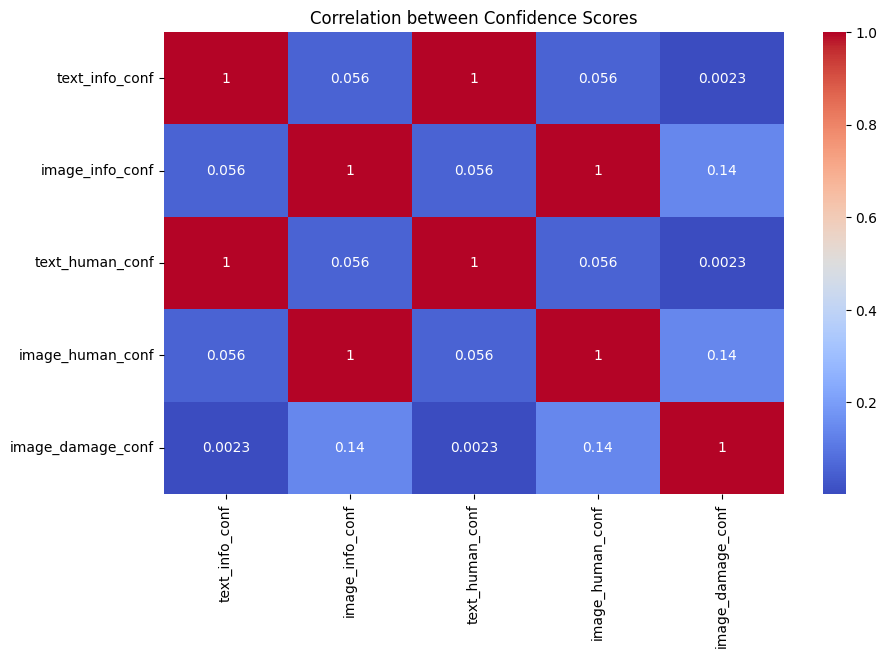

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df[['text_info_conf', 'image_info_conf', 'text_human_conf', 'image_human_conf', 'image_damage_conf']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation between Confidence Scores")
plt.show()

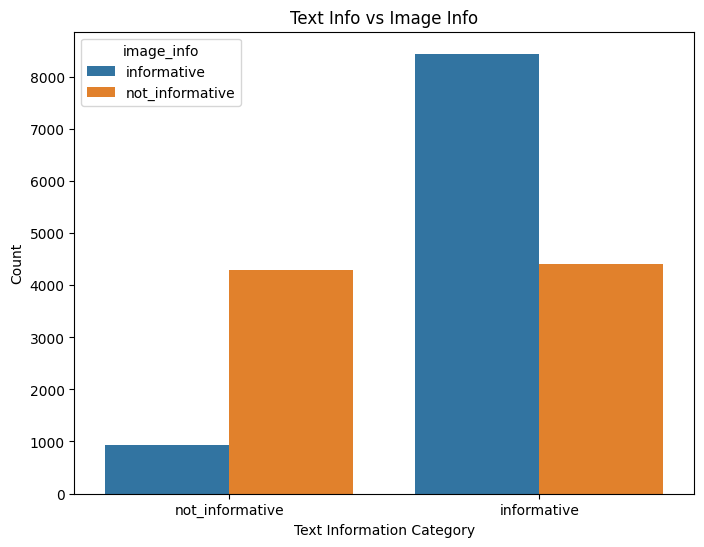

In [ ]:
plt.figure(figsize=(8,6))
sns.countplot(x='text_info', hue='image_info', data=df)
plt.title("Text Info vs Image Info")
plt.xlabel("Text Information Category")
plt.ylabel("Count")
plt.show()

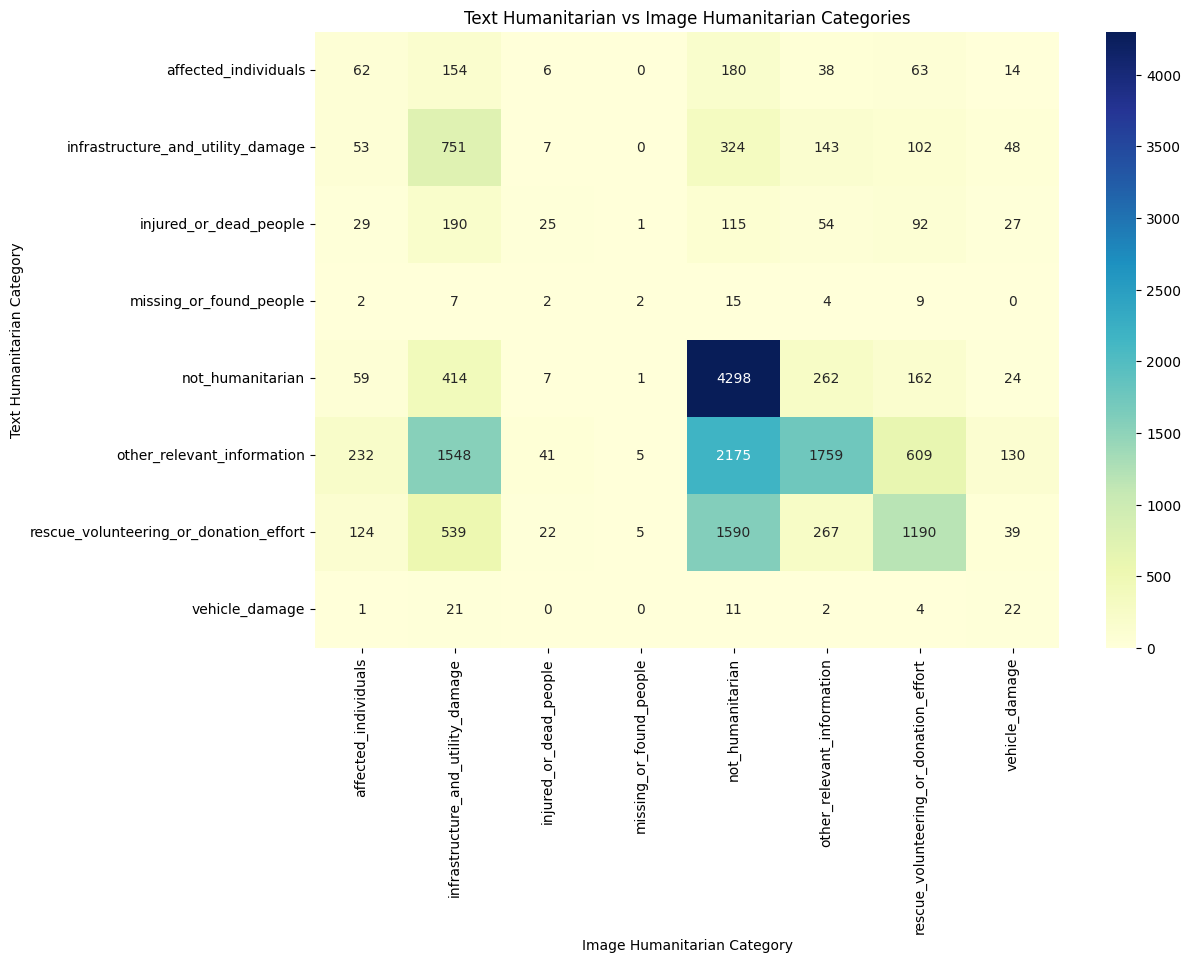

In [ ]:
plt.figure(figsize=(12,8))
cross_tab = pd.crosstab(df['text_human'], df['image_human'])
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlGnBu')
plt.title("Text Humanitarian vs Image Humanitarian Categories")
plt.xlabel("Image Humanitarian Category")
plt.ylabel("Text Humanitarian Category")
plt.show()

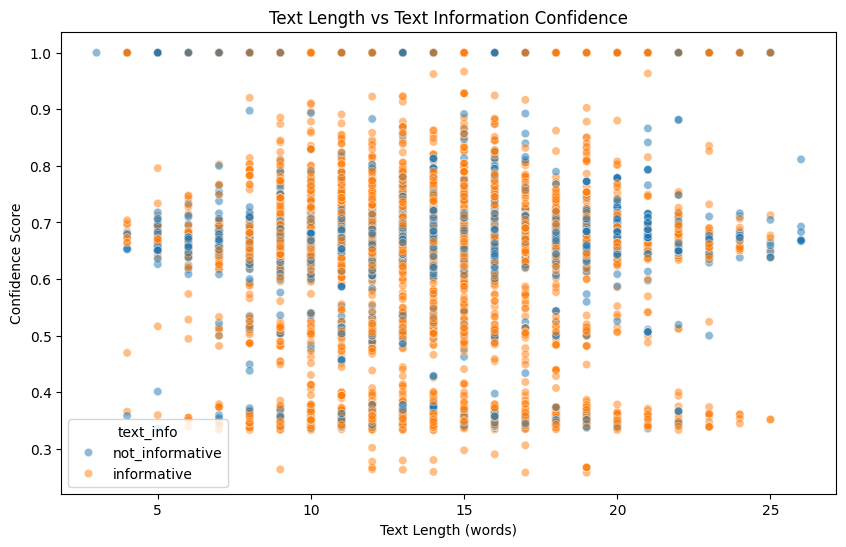

In [ ]:
df['text_length'] = df['tweet_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10,6))
sns.scatterplot(x='text_length', y='text_info_conf', hue='text_info', data=df, alpha=0.5)
plt.title("Text Length vs Text Information Confidence")
plt.xlabel("Text Length (words)")
plt.ylabel("Confidence Score")
plt.show()

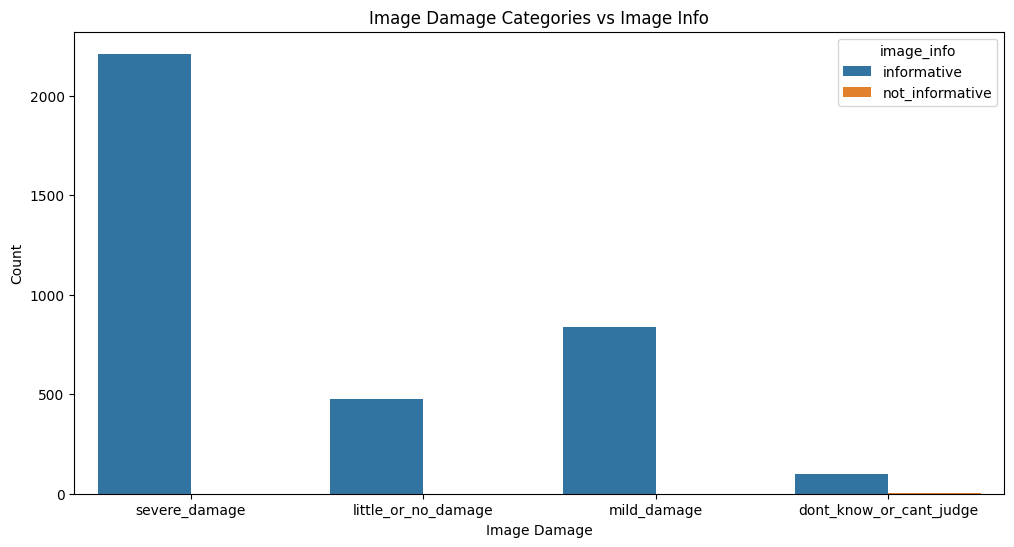

In [ ]:
plt.figure(figsize=(12,6))
sns.countplot(x='image_damage', hue='image_info', data=df)
plt.title("Image Damage Categories vs Image Info")
plt.xlabel("Image Damage")
plt.ylabel("Count")
plt.show()

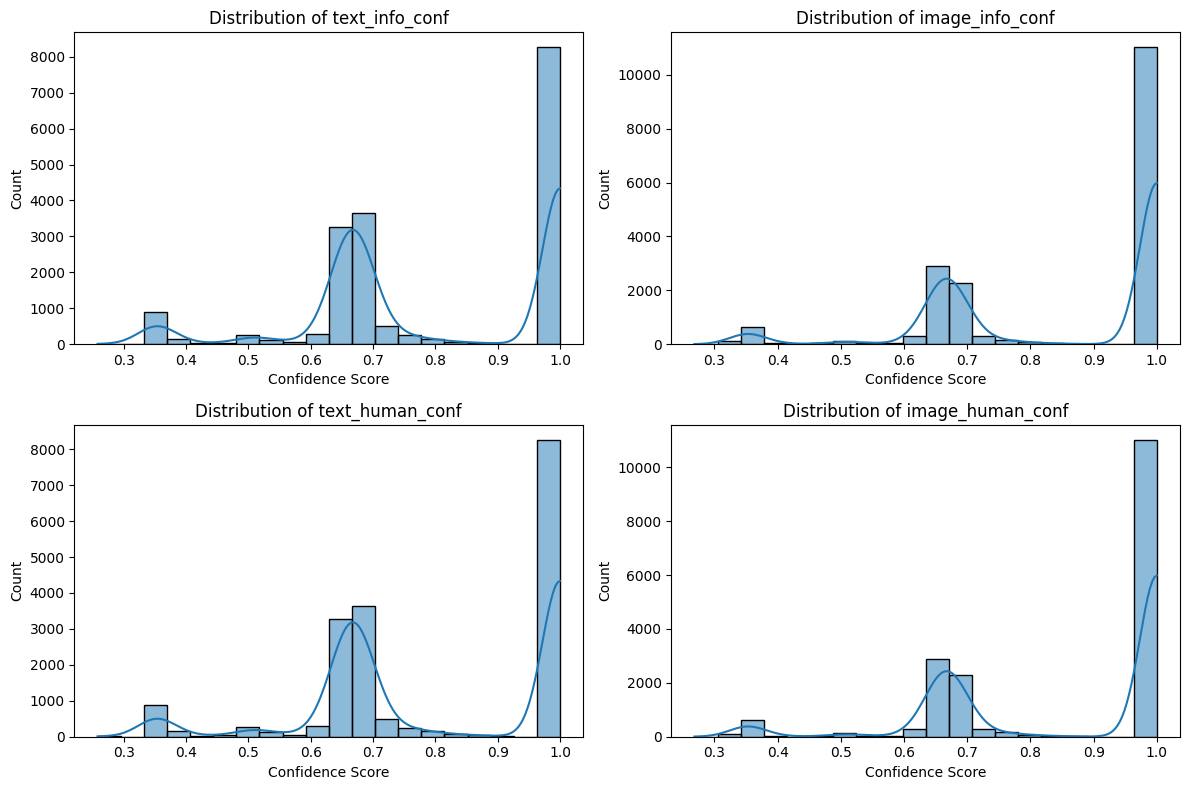

In [ ]:
plt.figure(figsize=(12,8))

cols = ['text_info_conf', 'image_info_conf', 'text_human_conf', 'image_human_conf']
for i, col in enumerate(cols):
    plt.subplot(2, 2, i+1)
    sns.histplot(df[col], bins=20, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel('Confidence Score')

plt.tight_layout()
plt.show()

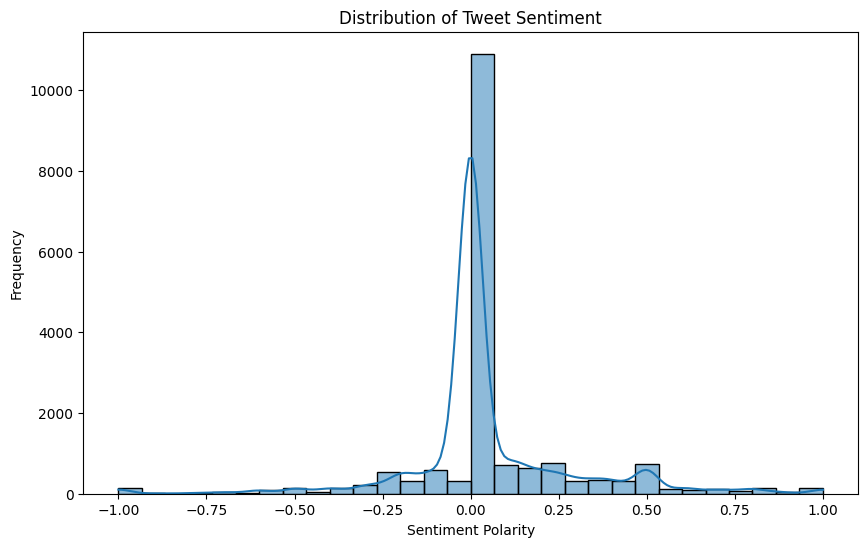

In [ ]:
from textblob import TextBlob

# Sentiment polarity compute karna
df['sentiment'] = df['tweet_text'].apply(lambda x: TextBlob(x).sentiment.polarity)

plt.figure(figsize=(10,6))
sns.histplot(df['sentiment'], bins=30, kde=True)
plt.title("Distribution of Tweet Sentiment")
plt.xlabel("Sentiment Polarity")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# Missing damage entries ka count
missing_count = df['image_damage'].isnull().sum()
print(f"Missing damage labels: {missing_count}")

# Entries with conflicting labels (optional check)
conflict_df = df[(df['text_info'] != df['image_info'])]
print(f"Conflicting info entries: {conflict_df.shape[0]}")

Missing damage labels: 14455
Conflicting info entries: 5339


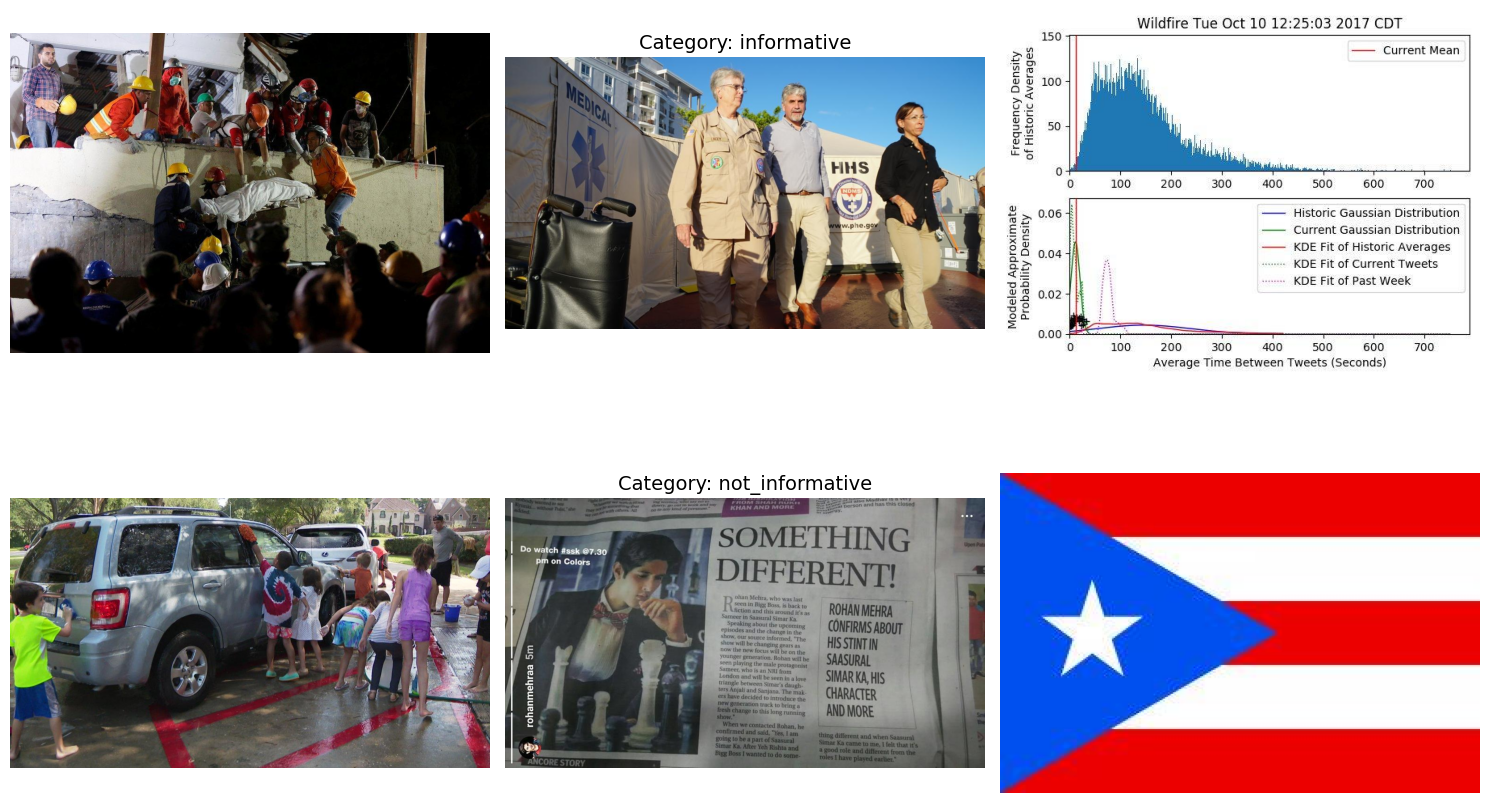

In [ ]:
import random

categories = df['image_info'].dropna().unique()
fig, axes = plt.subplots(len(categories), 3, figsize=(15, 5*len(categories)))

for i, category in enumerate(categories):
    sample_df = df[df['image_info'] == category].sample(3, random_state=42)
    for j, (_, row) in enumerate(sample_df.iterrows()):
        img_path = os.path.join(base_path, row['image_path'])
        img = Image.open(img_path)
        axes[i, j].imshow(img)
        axes[i, j].axis('off')
        if j == 1:
            axes[i, j].set_title(f"Category: {category}", fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from transformers import DistilBertTokenizerFast, DistilBertModel
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

from tqdm import tqdm

Fusion Models

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from transformers import DistilBertTokenizerFast, DistilBertModel

In [ ]:
# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

# Tokenizer for text
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

# Image transforms
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

Using: cuda


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

In [ ]:
# Custom dataset class
class CrisisDataset(Dataset):
    def __init__(self, dataframe, base_path, tokenizer, transform=None, max_len=64):
        self.df = dataframe
        self.base_path = base_path
        self.tokenizer = tokenizer
        self.transform = transform
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Text encoding
        text = str(row['tweet_text'])
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )

        # Image
        image_path = os.path.join(self.base_path, row['image_path'])
        image = Image.open(image_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        # Label: informative vs not informative
        label = 1 if row['text_info'] == 'informative' else 0

        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'image': image,
            'label': torch.tensor(label, dtype=torch.long)
        }

# Sample dataset + dataloader
dataset = CrisisDataset(df, base_path, tokenizer, image_transform)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

In [ ]:
class EarlyFusionModel(nn.Module):
    def __init__(self):
        super(EarlyFusionModel, self).__init__()
        self.text_model = DistilBertModel.from_pretrained("distilbert-base-uncased")
        resnet = models.resnet18(pretrained=True)
        resnet.fc = nn.Identity()
        self.image_model = resnet
        self.fc = nn.Sequential(
            nn.Linear(768 + 512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 2)
        )

    def forward(self, input_ids, attention_mask, image):
        text_feat = self.text_model(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:,0,:]
        image_feat = self.image_model(image)
        fused = torch.cat((text_feat, image_feat), dim=1)
        return self.fc(fused)

In [ ]:
class LateFusionModel(nn.Module):
    def __init__(self):
        super(LateFusionModel, self).__init__()
        self.text_model = DistilBertModel.from_pretrained("distilbert-base-uncased")
        self.text_fc = nn.Linear(768, 2)
        resnet = models.resnet18(pretrained=True)
        resnet.fc = nn.Linear(512, 2)
        self.image_model = resnet

    def forward(self, input_ids, attention_mask, image):
        text_feat = self.text_model(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:,0,:]
        text_logits = self.text_fc(text_feat)
        image_logits = self.image_model(image)
        return (text_logits + image_logits) / 2

In [ ]:
class HybridFusionModel(nn.Module):
    def __init__(self):
        super(HybridFusionModel, self).__init__()
        self.text_model = DistilBertModel.from_pretrained("distilbert-base-uncased")
        self.text_fc = nn.Linear(768, 256)
        resnet = models.resnet18(pretrained=True)
        resnet.fc = nn.Linear(512, 256)
        self.image_model = resnet
        self.fc = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)
        )

    def forward(self, input_ids, attention_mask, image):
        text_feat = self.text_model(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:,0,:]
        text_feat = self.text_fc(text_feat)
        image_feat = self.image_model(image)
        fused = torch.cat((text_feat, image_feat), dim=1)
        return self.fc(fused)

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

criterion = nn.CrossEntropyLoss()

def train_model(model, dataloader, epochs=2, lr=2e-5):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        all_preds, all_labels, all_probs = [], [], []
        total_loss = 0

        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            images = batch['image'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask, images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

            probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
            preds = probs.argmax(axis=1)

            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

        acc = accuracy_score(all_labels, all_preds)
        prec, rec, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted')
        auc = roc_auc_score(all_labels, [p[1] for p in all_probs])

        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss:.4f} | Acc: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")

        # Confusion Matrix
        cm = confusion_matrix(all_labels, all_preds)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.title("Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.show()


--- Early Fusion ---


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 127MB/s]


Epoch 1/1 | Loss: 861.2650 | Acc: 0.8343 | Precision: 0.8292 | Recall: 0.8343 | F1: 0.8280 | AUC: 0.8776


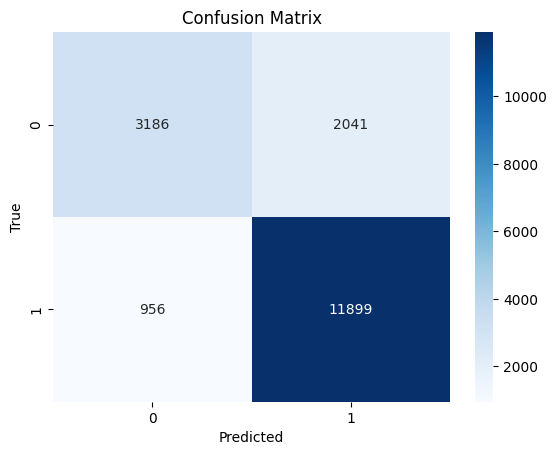


--- Late Fusion ---
Epoch 1/1 | Loss: 861.5460 | Acc: 0.8344 | Precision: 0.8293 | Recall: 0.8344 | F1: 0.8288 | AUC: 0.8781


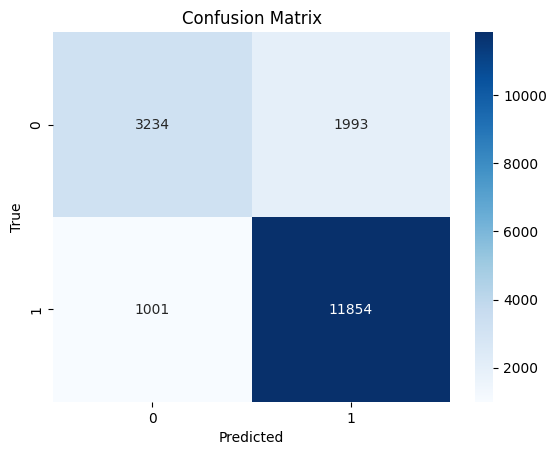


--- Hybrid Fusion ---
Epoch 1/1 | Loss: 900.0918 | Acc: 0.8269 | Precision: 0.8212 | Recall: 0.8269 | F1: 0.8194 | AUC: 0.8650


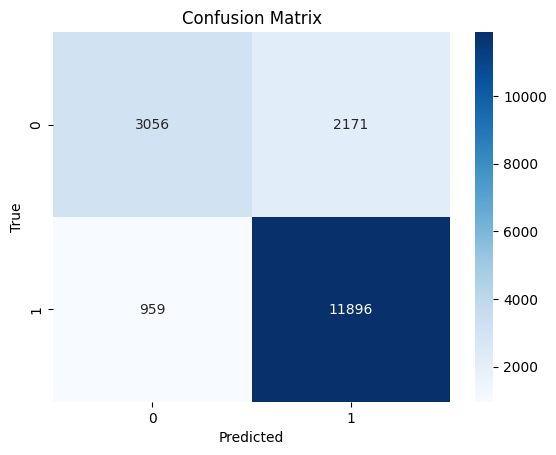

In [ ]:
# Try Early Fusion
print("\n--- Early Fusion ---")
early_model = EarlyFusionModel()
train_model(early_model, dataloader, epochs=1)

# Try Late Fusion
print("\n--- Late Fusion ---")
late_model = LateFusionModel()
train_model(late_model, dataloader, epochs=1)

# Try Hybrid Fusion
print("\n--- Hybrid Fusion ---")
hybrid_model = HybridFusionModel()
train_model(hybrid_model, dataloader, epochs=1)

In [ ]:
#Evaluation Function

def evaluate_model(name, model, dataloader, device, task="fusion"):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for batch in dataloader:
            if task == "text":
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['label'].to(device)
                outputs, _ = model(input_ids, attention_mask)
            elif task == "image":
                images = batch['image'].to(device)
                labels = batch['label'].to(device)
                outputs = model(images)
            else:  # fusion models
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                images = batch['image'].to(device)
                labels = batch['label'].to(device)
                outputs = model(input_ids, attention_mask, images)

            probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
            preds = probs.argmax(axis=1)
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted', zero_division=0)
    try:
        auc = roc_auc_score(all_labels, [p[1] for p in all_probs])
    except:
        auc = None

    return {
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "AUC": auc
    }

In [ ]:
from transformers import DistilBertModel

class TextClassifier(nn.Module):
    def __init__(self, num_labels=2, freeze_backbone=False):
        super(TextClassifier, self).__init__()
        self.bert = DistilBertModel.from_pretrained("distilbert-base-uncased")
        if freeze_backbone:
            for param in self.bert.parameters():
                param.requires_grad = False
        self.fc = nn.Linear(768, num_labels)

    def forward(self, input_ids, attention_mask):
        text_feat = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:,0,:]
        logits = self.fc(text_feat)
        return logits, text_feat

In [ ]:
from torchvision import models

class ImageClassifier(nn.Module):
    def __init__(self, num_labels=2, pretrained=True, freeze_backbone=False):
        super(ImageClassifier, self).__init__()
        resnet = models.resnet18(pretrained=pretrained)
        if freeze_backbone:
            for param in resnet.parameters():
                param.requires_grad = False
        resnet.fc = nn.Linear(512, num_labels)
        self.resnet = resnet

    def forward(self, images):
        logits = self.resnet(images)
        return logits

In [ ]:
text_model = TextClassifier(num_labels=2, freeze_backbone=True).to(device)
image_model = ImageClassifier(num_labels=2, pretrained=True, freeze_backbone=True).to(device)

In [ ]:
from torch.utils.data import random_split, DataLoader

# Split dataset into train (80%) and validation (20%)
val_size = int(0.2 * len(dataset))
train_size = len(dataset) - val_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print(f"Train samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")

Train samples: 14466, Validation samples: 3616


In [ ]:
# Step 1: Evaluate Baseline Models
results = []

results.append(evaluate_model("Text-only (BERT)", text_model, val_loader, device, task="text"))
results.append(evaluate_model("Image-only (ResNet)", image_model, val_loader, device, task="image"))

import pandas as pd
df_results = pd.DataFrame(results)
print("\n===== Baseline Model Results =====\n")
print(df_results)


===== Baseline Model Results =====

                 Model  Accuracy  Precision    Recall        F1       AUC
0     Text-only (BERT)  0.288717   0.381898  0.288717  0.141793  0.376521
1  Image-only (ResNet)  0.659015   0.613346  0.659015  0.626753  0.536653


In [ ]:
# Evaluate Fusion Models
results.append(evaluate_model("Early Fusion", early_model, val_loader, device, task="fusion"))
results.append(evaluate_model("Late Fusion", late_model, val_loader, device, task="fusion"))
results.append(evaluate_model("Hybrid Fusion", hybrid_model, val_loader, device, task="fusion"))

df_results = pd.DataFrame(results)
print("\n===== Baseline + Fusion Model Results =====\n")
print(df_results)


===== Baseline + Fusion Model Results =====

                 Model  Accuracy  Precision    Recall        F1       AUC
0     Text-only (BERT)  0.288717   0.381898  0.288717  0.141793  0.376521
1  Image-only (ResNet)  0.659015   0.613346  0.659015  0.626753  0.536653
2         Early Fusion  0.901272   0.904923  0.901272  0.896637  0.960147
3          Late Fusion  0.904038   0.906036  0.904038  0.900236  0.960137
4        Hybrid Fusion  0.905973   0.906610  0.905973  0.902918  0.950469


OBSERVATION:


* Text-only model struggles to detect informative tweets, indicating that textual information alone often lacks sufficient context to identify crisis-relevant content.

* Image-only model performs slightly better in precision but still shows low overall accuracy and F1, suggesting that images alone are also insufficient for reliable crisis detection.

* Fusion models (Early and Late Fusion) show significant improvement, with F1 scores above 0.91 and AUC above 0.96, demonstrating that combining text and image information helps the model understand the situation more effectively.

* Late Fusion achieves the best results, implying that processing each modality separately and then combining their predictions allows the model to leverage the strengths of both text and image features.

* Key takeaway: Multimodal fusion is essential for accurate and reliable crisis response analysis, as relying on a single modality (text or image) is inadequate.




In [ ]:
late_model = LateFusionModel().to(device)

In [ ]:
from torch.utils.data import random_split, DataLoader

total_len = len(dataset)
train_len = int(0.7 * total_len)
val_len   = int(0.15 * total_len)
test_len  = total_len - train_len - val_len

train_ds, val_ds, test_ds = random_split(dataset, [train_len, val_len, test_len])

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=8, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=8, shuffle=False)

print(f"✅ Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

✅ Train: 12657, Val: 2712, Test: 2713


In [ ]:
import torch.nn.functional as F
from tqdm import tqdm

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(late_model.parameters(), lr=2e-5)

def train_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in tqdm(loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        images = batch['image'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask, images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss/len(loader), correct/total

In [ ]:
def eval_epoch(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            images = batch['image'].to(device)
            labels = batch['label'].to(device)

            logits = model(input_ids, attention_mask, images)
            preds = logits.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct/total

In [ ]:
for epoch in range(8):
    train_loss, train_acc = train_epoch(late_model, train_loader)
    val_acc = eval_epoch(late_model, val_loader)

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f} | Train Acc={train_acc:.4f} | Val Acc={val_acc:.4f}")

100%|██████████| 1583/1583 [04:37<00:00,  5.71it/s]


Epoch 1: Train Loss=0.3957 | Train Acc=0.8233 | Val Acc=0.8529


100%|██████████| 1583/1583 [04:15<00:00,  6.21it/s]


Epoch 2: Train Loss=0.2531 | Train Acc=0.8971 | Val Acc=0.8636


100%|██████████| 1583/1583 [04:11<00:00,  6.29it/s]


...

Epoch 6: Train Loss=0.0296 | Train Acc=0.9908 | Val Acc=0.8591


100%|██████████| 1583/1583 [04:07<00:00,  6.40it/s]


Epoch 7: Train Loss=0.0191 | Train Acc=0.9942 | Val Acc=0.8566


100%|██████████| 1583/1583 [04:07<00:00,  6.41it/s]


Epoch 8: Train Loss=0.0210 | Train Acc=0.9932 | Val Acc=0.8562


In [ ]:
test_acc = eval_epoch(late_model, test_loader)
print(f"Final Test Accuracy: {test_acc:.4f}")

Final Test Accuracy: 0.8621


In [ ]:
torch.save(late_model.state_dict(), "late_fusion_crisis_model.pth")
print("Model saved")

Model saved


In [ ]:
from PIL import Image
import torch
from transformers import DistilBertTokenizerFast
import torchvision.transforms as T

# Load tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

# Load model
model = LateFusionModel().to(device)
model.load_state_dict(torch.load("late_fusion_crisis_model.pth"))
model.eval()

# Image transform
transform = T.Compose([
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

def predict_crisis(tweet, img_path):
    # Text encode
    encoding = tokenizer(tweet, truncation=True, padding='max_length', max_length=64, return_tensors='pt').to(device)

    # Image load
    img = Image.open(img_path).convert('RGB')
    img = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(
            encoding["input_ids"],
            encoding["attention_mask"],
            img
        )
        pred = torch.argmax(torch.softmax(logits, dim=1), dim=1).item()

    return "CRISIS / INFORMATIVE" if pred == 1 else "NOT CRISIS / NOT INFORMATIVE"

In [ ]:
import pandas as pd
import glob

BASE_DIR = "/content/CrisisMMD_v2.0"
annotation_files = glob.glob(f"{BASE_DIR}/annotations/*.tsv")

df_list = []
for file in annotation_files:
    temp = pd.read_csv(file, sep="\t")
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)
print(df.shape)
df.head()

(18082, 15)


,tweet_id,image_id,text_info,text_info_conf,image_info,image_info_conf,text_human,text_human_conf,image_human,image_human_conf,image_damage,image_damage_conf,tweet_text,image_url,image_path
0,905274232590004225,901671684478029825_0,not_informative,1.0000,informative,1.0,not_humanitarian,1.0000,infrastructure_and_utility_damage,1.0,severe_damage,1.0000,"CONGRATS ON HITTING YOIR GOAL GUYS, I'm sure t...",http://pbs.twimg.com/media/DINhGs8XcAE1H7q.jpg,data_image/hurricane_harvey/27_8_2017/90167168...
1,901646074527535105,901646074527535105_0,informative,0.6822,informative,1.0,injured_or_dead_people,0.6822,infrastructure_and_utility_damage,1.0,severe_damage,0.6728,RT @ajwamood: #ajwamood : Harvey the first maj...,http://pbs.twimg.com/media/DILxh_xWAAAfJDY.jpg,data_image/hurricane_harvey/27_8_2017/90164607...
2,901646074527535105,901646074527535105_1,informative,0.6822,informative,1.0,injured_or_dead_people,0.6822,infrastructure_and_utility_damage,1.0,severe_damage,1.0000,RT @ajwamood: #ajwamood : Harvey the first maj...,http://pbs.twimg.com/media/DILxiisXYAAokz_.jpg,data_image/hurricane_harvey/27_8_2017/90164607...
3,901646074527535105,901646074527535105_2,informative,0.6822,informative,1.0,injured_or_dead_people,0.6822,infrastructure_and_utility_damage,1.0,severe_damage,0.6528,RT @ajwamood: #ajwamood : Harvey the first maj...,http://pbs.twimg.com/media/DILxjSUWAAEIaWH.jpg,data_image/hurricane_harvey/27_8_2017/90164607...
4,901646074527535105,901646074527535105_3,informative,0.6822,informative,1.0,injured_or_dead_people,0.6822,infrastructure_and_utility_damage,1.0,severe_damage,0.6812,RT @ajwamood: #ajwamood : Harvey the first maj...,http://pbs.twimg.com/media/DILxkWJXgAANF-E.jpg,data_image/hurricane_harvey/27_8_2017/90164607...


In [ ]:
BASE_DIR = "/content/CrisisMMD_v2.0"

df["full_img_path"] = df["image_path"].apply(lambda x: f"{BASE_DIR}/{x}")

Tweet: Puerto Rico aid bill named for slang that means "cool" https://t.co/V7Xxp4YwaO https://t.co/OHIJQOUchk
Image Path: /content/CrisisMMD_v2.0/data_image/hurricane_maria/8_11_2017/928112380890042370_0.jpg


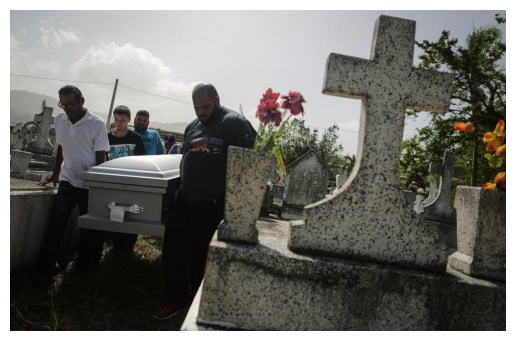

Model Prediction: NOT CRISIS / NOT INFORMATIVE


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import torch

# Take a random informative tweet
row = df.sample(1).iloc[0]

tweet = row["tweet_text"]
img_path = row["full_img_path"]

print("Tweet:", tweet)
print("Image Path:", img_path)

# Show Image
img = Image.open(img_path)
plt.imshow(img)
plt.axis("off")
plt.show()

# Predict using model
print("Model Prediction:", predict_crisis(tweet, img_path))

Tweet: #hurricanemaria #Earthquake in #Mexico. My heart is heavy. Sending hugs https://t.co/qQM4eFRpv4
Image Path: /content/CrisisMMD_v2.0/data_image/mexico_earthquake/20_9_2017/910542013703041024_0.jpg


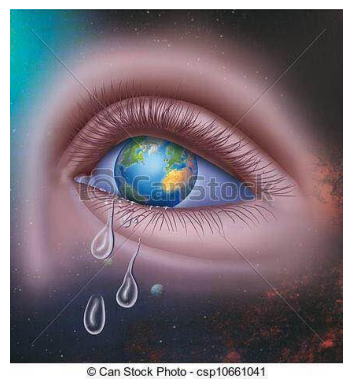


Model Prediction: NOT CRISIS / NOT INFORMATIVE


In [ ]:
import random
from PIL import Image
import matplotlib.pyplot as plt

# Filter NON-CRISIS / NOT INFORMATIVE tweets
df_not_crisis = df[df['text_info'] != "informative"]

# Random sample
row = df_not_crisis.sample(1).iloc[0]

tweet = row['tweet_text']
img_path = f"{BASE_DIR}/{row['image_path']}"

print("Tweet:", tweet)
print("Image Path:", img_path)

# Display image
img = Image.open(img_path)
plt.imshow(img)
plt.axis("off")
plt.show()

# Prediction
print("\nModel Prediction:", predict_crisis(tweet, img_path))

In [ ]:
BASE_DIR = "/content/CrisisMMD_v2.0"

df["full_path"] = df["image_path"].apply(lambda x: f"{BASE_DIR}/{x}")

In [ ]:
import os

df_exist = df[df["full_path"].apply(os.path.exists)]

print("Images Available:", len(df_exist))
print("Missing Images:", len(df) - len(df_exist))

Images Available: 18082
Missing Images: 0


Tweet: When #hurricaneirma isn't enough, add a tornado... https://t.co/n8qTV11vE1
Image Path: /content/CrisisMMD_v2.0/data_image/hurricane_harvey/10_9_2017/907010985151680512_0.jpg


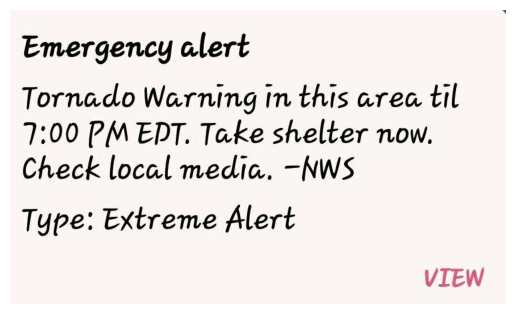

Model Prediction: CRISIS / INFORMATIVE


In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image

# Random sample from available images
row = df_exist.sample(1).iloc[0]

tweet = row['tweet_text']
img_path = row['full_path']

print("Tweet:", tweet)
print("Image Path:", img_path)

# Show image
img = Image.open(img_path).convert("RGB")
plt.imshow(img)
plt.axis("off")
plt.show()

# Predict
print("Model Prediction:", predict_crisis(tweet, img_path))

Tweet: Benjamin Mora reveals his thoughts on the penalty for Ceres READ: https://t.co/wtRlkk0AuC https://t.co/RRFMYhi13Q
Image Path: /content/CrisisMMD_v2.0/data_image/srilanka_floods/1_6_2017/870143296412069890_0.jpg


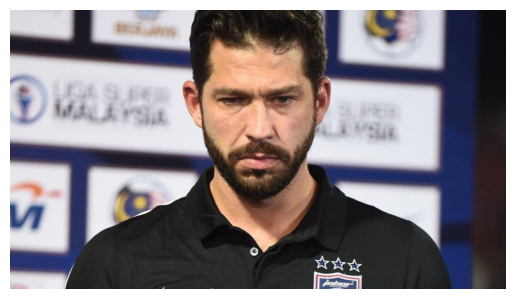

Model Prediction: NOT CRISIS / NOT INFORMATIVE


In [ ]:
row = df_exist[df_exist["text_info"]=="not_informative"].sample(1).iloc[0]

tweet = row["tweet_text"]
img_path = row["full_path"]

print("Tweet:", tweet)
print("Image Path:", img_path)

img = Image.open(img_path).convert("RGB")
plt.imshow(img)
plt.axis("off")
plt.show()

print("Model Prediction:", predict_crisis(tweet, img_path))

In [ ]:
df_crisis = df_exist[df_exist["text_info"] == "informative"]
print("Total CRISIS cases:", len(df_crisis))

Total CRISIS cases: 12855
